In [1]:
"""
Sycophancy Rate by Language — Bar Chart
========================================
Drop this into a Jupyter notebook cell. Reads the *_clean.csv output
from merge_and_clean.py.

Produces a horizontal bar chart with:
  - Sycophancy rate (%) per language
  - N annotations per language
  - 95% Wilson confidence intervals
  - Color-coded bars (gradient by rate)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:


CLEAN_CSV = "results/rq1_clean.csv"   
LANG_COL = "lang"
LABEL_COL = "judge_label"
SAVE_PATH = "figures/sycophancy_by_lang.pdf"


In [3]:



df = pd.read_csv(CLEAN_CSV)

# ─── Compute sycophancy rate + Wilson CI per language ─────
def wilson_ci(n_success, n_total, z=1.96):
    """Wilson score interval for a binomial proportion."""
    if n_total == 0:
        return 0, 0, 0
    p = n_success / n_total
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    margin = (z / denom) * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2))
    return centre, max(0, centre - margin), min(1, centre + margin)

rows = []
for lang in sorted(df[LANG_COL].unique()):
    if lang == "japanese":
        continue
    sub = df[df[LANG_COL] == lang]
    n = len(sub)
    n_syc = (sub[LABEL_COL] == 0).sum()
    rate, ci_lo, ci_hi = wilson_ci(n_syc, n)
    rows.append({
        "language": lang.capitalize(),
        "n": n,
        "n_sycophantic": n_syc,
        "sycophancy_rate": rate * 100,
        "ci_lo": ci_lo * 100,
        "ci_hi": ci_hi * 100,
    })

stats = pd.DataFrame(rows).sort_values("sycophancy_rate", ascending=True)




Saved to figures/sycophancy_by_lang.pdf


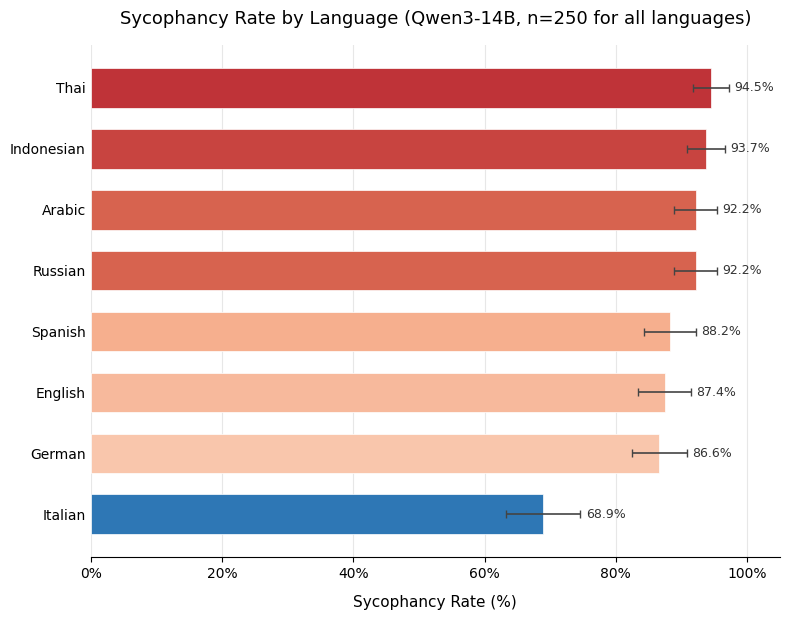

In [4]:
# ─── Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 0.6 * len(stats) + 1.5))

# Color gradient: colorblind-friendly blue→orange (low→high sycophancy)
# Using a custom linear gradient from steel blue to warm orange
from matplotlib.colors import LinearSegmentedColormap
cmap = cmap = plt.cm.RdBu_r
#LinearSegmentedColormap.from_list(
#    "cb_safe", ["#4477AA", "#DDCC77", "#CC6677"]  # blue → gold → rose (Tol's muted)
#)


norm = plt.Normalize(stats["sycophancy_rate"].min() - 5, stats["sycophancy_rate"].max() + 5)

bars = ax.barh(
    stats["language"],
    stats["sycophancy_rate"],
    color=[cmap(norm(v)) for v in stats["sycophancy_rate"]],
    edgecolor="white",
    linewidth=0.5,
    height=0.65,
    zorder=3,
)

# Error bars (Wilson CI)
xerr_lo = stats["sycophancy_rate"] - stats["ci_lo"]
xerr_hi = stats["ci_hi"] - stats["sycophancy_rate"]
ax.errorbar(
    stats["sycophancy_rate"],
    stats["language"],
    xerr=[xerr_lo.values, xerr_hi.values],
    fmt="none",
    ecolor="#444444",
    elinewidth=1.2,
    capsize=3,
    zorder=4,
)

# Annotations: rate + (n=...)
for i, (_, row) in enumerate(stats.iterrows()):
    ax.text(
        row["ci_hi"] + 0.8, i,
        f'{row["sycophancy_rate"]:.1f}%',
        va="center", ha="left", fontsize=9, color="#333333",
    )

# Styling
ax.set_xlabel("Sycophancy Rate (%)", fontsize=11, labelpad=10)
ax.set_xlim(0, min(stats["ci_hi"].max() + 15, 105))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("Sycophancy Rate by Language (Qwen3-14B, n=250 for all languages)", fontsize=13, pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.grid(axis="x", alpha=0.3, zorder=0)

plt.tight_layout()

if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
    print(f"Saved to {SAVE_PATH}")

plt.show()

In [ ]:

# ─── Print table for paper ────────────────────────────────
print("\nLanguage          Syc%     95% CI         N")
print("-" * 48)
for _, row in stats.sort_values("sycophancy_rate", ascending=False).iterrows():
    print(f"  {row['language']:<15} {row['sycophancy_rate']:>5.1f}%  "
          f"[{row['ci_lo']:>5.1f}, {row['ci_hi']:>5.1f}]  {row['n']:>5.0f}")


Language          Syc%     95% CI         N
------------------------------------------------
  Thai             94.5%  [ 91.8,  97.2]    250
  Indonesian       93.7%  [ 90.8,  96.6]    250
  Arabic           92.2%  [ 88.9,  95.4]    250
  Russian          92.2%  [ 88.9,  95.4]    250
  Spanish          88.2%  [ 84.3,  92.1]    250
  English          87.4%  [ 83.4,  91.5]    250
  Japanese         87.4%  [ 83.4,  91.5]    250
  German           86.6%  [ 82.5,  90.8]    250
  Italian          68.9%  [ 63.2,  74.6]    250


In [21]:
import plotly.graph_objects as go
import numpy as np

# ─── Color mapping (match heatmap: RdBu, same zmin/zmax logic) ─────
from plotly.colors import sample_colorscale

# Normalize sycophancy rates to [0, 1] for colorscale sampling
rate_min = stats["sycophancy_rate"].min() - 5
rate_max = stats["sycophancy_rate"].max() + 5
norm_vals = (stats["sycophancy_rate"] - rate_min) / (rate_max - rate_min)
bar_colors = sample_colorscale("RdBu_r", norm_vals.clip(0, 1).tolist())

# ─── Plot ─────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(
    y=stats["language"],
    x=stats["sycophancy_rate"],
    orientation="h",
    marker=dict(color=bar_colors, line=dict(color="white", width=0.5)),
    error_x=dict(
        type="data",
        symmetric=False,
        array=(stats["ci_hi"] - stats["sycophancy_rate"]).tolist(),
        arrayminus=(stats["sycophancy_rate"] - stats["ci_lo"]).tolist(),
        color="#444444",
        thickness=1.2,
        width=3,
    ),
    #text=[f"{v:.1f}%" for v in stats["sycophancy_rate"]],
    #textposition="outside",
    #textfont=dict(color="black", size=11),
))

for _, row in stats.iterrows():
    fig.add_annotation(
        x=row["ci_hi"] + 0.8,
        y=row["language"],
        text=f'{row["sycophancy_rate"]:.1f}%',
        showarrow=False,
        xanchor="left",
        font=dict(color="black", size=11),
    )
    
fig.update_layout(
    title=dict(
        text="Sycophancy Rate by Language (Qwen3-14B, n=250 per language)",
        font=dict(size=14), x=0.5,
        xanchor="center",
    ),
    xaxis=dict(
        title="Sycophancy Rate (%)",
        range=[0, min(stats["ci_hi"].max() + 15, 105)],
        ticksuffix="%",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)",
    ),
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=11),
    ),
    font=dict(size=11),
    height=min(350, 60 * len(stats) + 100),
    width=550,
    plot_bgcolor="white",
    margin=dict(l=10, r=40, t=60, b=40),
)

if SAVE_PATH:
    fig.write_image("figures/rq1_sycophancy_rates.svg")
    print(f"Saved to {SAVE_PATH}")

fig.show()

Saved to figures/sycophancy_by_lang.pdf
